# Model Comparison Analysis

Analysis of predictions generated by 6 classifiers on the v2 test set.
Data: 2023 MLB Statcast, all pitchers, 9 pitch types, 18,000 test samples.


In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from statsmodels.stats.contingency_tables import cochrans_q
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

df = pd.read_csv('../results/metrics/predictions.csv')

MODEL_NAMES = ['logistic_regression', 'decision_tree', 'knn', 'random_forest', 'mlp', 'xgboost', 'xgboost_hierarchical']
CLASSES = sorted(df['y_true'].unique())

print(f'Test samples: {len(df)}')
print(f'Classes: {CLASSES}')
print(f'Columns: {list(df.columns)}')


Test samples: 18000
Classes: ['CH', 'CU', 'FC', 'FF', 'FS', 'KC', 'SI', 'SL', 'ST']
Columns: ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z', 'release_pos_x', 'release_pos_z', 'plate_x', 'plate_z', 'release_extension', 'p_throws', 'spin_axis', 'y_true', 'logistic_regression_pred', 'logistic_regression_probs', 'xgboost_pred', 'xgboost_probs', 'random_forest_pred', 'random_forest_probs', 'knn_pred', 'knn_probs', 'xgboost_specialist_pred', 'xgboost_specialist_probs', 'decision_tree_pred', 'decision_tree_probs', 'mlp_pred', 'mlp_probs', 'xgboost_hierarchical_pred']


## 1. Overall Performance Comparison


In [2]:
def load_training_time(model_name):
    path = f'../results/metrics/{model_name}.json'
    with open(path) as f:
        data = json.load(f)
    seconds = data.get('training_time_seconds', None)
    if seconds is None:
        return None
    return str(pd.to_timedelta(seconds, unit='s')).split('.')[0].split(' ')[-1]


def load_model_metrics(model_name):
    path = f'../results/metrics/{model_name}.json'
    with open(path) as f:
        data = json.load(f)
    return {
        'f1':        round(data['weighted avg']['f1-score'], 4),
        'precision': round(data['weighted avg']['precision'], 4),
        'recall':    round(data['weighted avg']['recall'], 4),
        'training_time': load_training_time(model_name),
    }

ML_MODELS = ['logistic_regression', 'decision_tree', 'knn', 'random_forest', 'mlp', 'xgboost']

rows = []
for model in ML_MODELS:
    row = {'model': model}
    row['f1']        = f1_score(df['y_true'], df[f'{model}_pred'], average='weighted')
    row['precision'] = precision_score(df['y_true'], df[f'{model}_pred'], average='weighted')
    row['recall']    = recall_score(df['y_true'], df[f'{model}_pred'], average='weighted')
    row['training_time'] = load_training_time(model)
    rows.append(row)

rule_based_row = {'model': 'rule_based'}
rule_based_row.update(load_model_metrics('rule_based'))
rows.append(rule_based_row)

import time

def add_times(t1: str, t2: str) -> str:
    total = pd.to_timedelta(t1) + pd.to_timedelta(t2)
    return str(total).split('.')[0].split(' ')[-1]

hier_training_time = add_times(
    load_training_time('xgboost'),
    load_training_time('xgboost_specialist')
)

hier_row = {
    'model':         'xgboost_hierarchical',
    'f1':            round(f1_score(df['y_true'], df['xgboost_hierarchical_pred'], average='weighted'), 4),
    'precision':     round(precision_score(df['y_true'], df['xgboost_hierarchical_pred'], average='weighted'), 4),
    'recall':        round(recall_score(df['y_true'], df['xgboost_hierarchical_pred'], average='weighted'), 4),
    'training_time': hier_training_time,
}
rows.append(hier_row)

summary = pd.DataFrame(rows).set_index('model').round(4).sort_values('f1', ascending=False)
summary


,f1,precision,recall,training_time
model,,,,
xgboost_hierarchical,0.9130,0.9133,0.9130,01:54:58
xgboost,0.9081,0.9084,0.9081,01:16:01
mlp,0.8943,0.8948,0.8944,11:13:51
random_forest,0.8910,0.8914,0.8910,01:43:51
knn,0.8812,0.8835,0.8823,00:24:55
decision_tree,0.8206,0.8205,0.8209,00:02:59
logistic_regression,0.5991,0.5985,0.6062,05:21:52
rule_based,0.5385,0.5650,0.5353,None


In [3]:
per_class = pd.DataFrame(index=CLASSES)

for model in MODEL_NAMES:
    per_class[model] = f1_score(df['y_true'], df[f'{model}_pred'], average=None, labels=CLASSES)

per_class = per_class.round(4)

# add this block before per_class['mean'] = ...
rule_based_per_class = {}
with open('../results/metrics/rule_based.json') as f:
    rb = json.load(f)
for cls in CLASSES:
    rule_based_per_class[cls] = rb[cls]['f1-score']
per_class['rule_based'] = pd.Series(rule_based_per_class)

per_class['xgboost_hierarchical'] = f1_score(df['y_true'], df['xgboost_hierarchical_pred'], average=None, labels=CLASSES)

per_class['mean'] = per_class.mean(axis=1).round(4)
per_class.sort_values('mean')


,logistic_regression,decision_tree,knn,random_forest,mlp,xgboost,xgboost_hierarchical,rule_based,mean
SL,0.3909,0.6595,0.7760,0.7681,0.7938,0.8063,0.830235,0.344215,0.6711
FC,0.5548,0.7701,0.8639,0.8434,0.8460,0.8639,0.883383,0.355115,0.7476
CH,0.4970,0.8370,0.8784,0.9062,0.9054,0.9221,0.922150,0.413051,0.7852
CU,0.5741,0.7829,0.8613,0.8873,0.8797,0.9009,0.900919,0.593998,0.7976
ST,0.6173,0.8379,0.8960,0.8968,0.9010,0.9192,0.919970,0.569835,0.8198
KC,0.5842,0.8321,0.8941,0.9178,0.9235,0.9303,0.930279,0.555907,0.8210
SI,0.6332,0.8934,0.9215,0.9344,0.9379,0.9457,0.945701,0.635066,0.8559
FS,0.8027,0.8792,0.9118,0.9325,0.9279,0.9404,0.940387,0.582256,0.8646
FF,0.7378,0.8933,0.9279,0.9321,0.9331,0.9444,0.944361,0.797341,0.8888


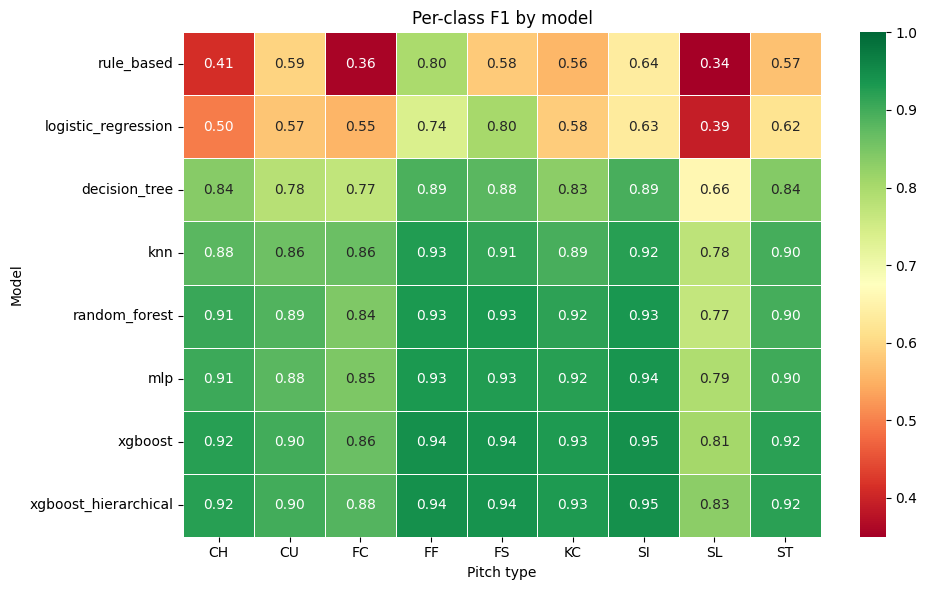

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

heatmap_data = per_class[['rule_based'] + MODEL_NAMES].T


sns.heatmap(heatmap_data,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            vmin=0.35,
            vmax=1.0,
            ax=ax,
            linewidths=0.5)

ax.set_title('Per-class F1 by model')
ax.set_xlabel('Pitch type')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('../results/figures/per_class_f1_heatmap.png', dpi=150)
plt.show()


**Hardest pitch types across all models:**
- SL (Slider) is the hardest class universally. Even XGBoost only reaches F1=0.81. Its overlap with ST (Sweeper) is likely inherent to how Statcast distinguishes the two.
- FC (Cutter) is the second hardest. It sits in the middle of the velocity and movement ranges, overlapping with both FF and SL.

**Easiest pitch types:**
- FF (Four-seam fastball) and FS (Splitter) are the most reliably classified across all models, driven by their distinctive velocity and spin profiles.

The feature set contains enough signal for ML models to classify pitch types reliably. The remaining errors on SL and FC are likely data-driven rather than modeling artifacts.


## 2. Statistical Significance Testing


In [5]:
# Leaving rule-based and logistic regression. Low performance obviously statitically significant.
EVAL_MODELS = ['decision_tree', 'knn', 'random_forest', 'mlp', 'xgboost', 'xgboost_hierarchical']

In [6]:
correct = pd.DataFrame({
    model: (df[f'{model}_pred'] == df['y_true']).astype(int)
    for model in EVAL_MODELS
})

result = cochrans_q(correct)
print(f"Cochran's Q statistic: {result.statistic:.4f}")
print(f'p-value: {result.pvalue:.6f}')
print()
if result.pvalue < 0.05:
    print('Result: significant difference exists among models. Proceed to pairwise tests.')
else:
    print('Result: no significant difference detected.')


Cochran's Q statistic: 2068.3990
p-value: 0.000000

Result: significant difference exists among models. Proceed to pairwise tests.


In [7]:
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations

n_comparisons = len(list(combinations(EVAL_MODELS, 2)))
bonferroni_threshold = 0.05 / n_comparisons
print(f'Bonferroni threshold: {bonferroni_threshold:.4f} ({n_comparisons} comparisons)\n')

mcnemar_rows = []
for model_a, model_b in combinations(EVAL_MODELS, 2):
    correct_a = df[f'{model_a}_pred'] == df['y_true']
    correct_b = df[f'{model_b}_pred'] == df['y_true']

    both_correct    = (correct_a & correct_b).sum()
    a_only          = (correct_a & ~correct_b).sum()
    b_only          = (~correct_a & correct_b).sum()
    both_wrong      = (~correct_a & ~correct_b).sum()

    table = [[both_correct, a_only], [b_only, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)

    mcnemar_rows.append({
        'model_a':     model_a,
        'model_b':     model_b,
        'statistic':   round(result.statistic, 4),
        'p_value':     round(result.pvalue, 6),
        'significant': result.pvalue < bonferroni_threshold
    })

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df


Bonferroni threshold: 0.0033 (15 comparisons)



,model_a,model_b,statistic,p_value,significant
0,decision_tree,knn,437.9442,0.000000,True
1,decision_tree,random_forest,739.4504,0.000000,True
2,decision_tree,mlp,616.9022,0.000000,True
3,decision_tree,xgboost,1012.1554,0.000000,True
4,decision_tree,xgboost_hierarchical,1102.6683,0.000000,True
5,knn,random_forest,16.1701,0.000058,True
6,knn,mlp,25.7025,0.000000,True
7,knn,xgboost,142.5326,0.000000,True
8,knn,xgboost_hierarchical,199.0229,0.000000,True
9,random_forest,mlp,2.2856,0.130577,False


In [8]:
BOOTSTRAP_PATH = '../results/metrics/bootstrap_scores.json'
N_BOOTSTRAP = 500

if os.path.exists(BOOTSTRAP_PATH):
    with open(BOOTSTRAP_PATH) as f:
        bootstrap_scores = json.load(f)
    print(f'Loaded bootstrap scores from {BOOTSTRAP_PATH}')
else:
    rng = np.random.default_rng(seed=42)
    y_true_arr = df['y_true'].values
    bootstrap_scores = {}

    for model in EVAL_MODELS:
        y_pred_arr = df[f'{model}_pred'].values
        scores = []
        for _ in range(N_BOOTSTRAP):
            idx = rng.integers(0, len(y_true_arr), size=len(y_true_arr))
            score = f1_score(y_true_arr[idx], y_pred_arr[idx], average='weighted')
            scores.append(score)
        bootstrap_scores[model] = scores

    with open(BOOTSTRAP_PATH, 'w') as f:
        json.dump(bootstrap_scores, f)
    print(f'Bootstrap scores saved to {BOOTSTRAP_PATH}')

bootstrap_rows = []
for model in EVAL_MODELS:
    scores = bootstrap_scores[model]
    bootstrap_rows.append({
        'model':    model,
        'mean':     round(np.mean(scores), 4),
        'ci_lower': round(np.percentile(scores, 2.5), 4),
        'ci_upper': round(np.percentile(scores, 97.5), 4),
    })

bootstrap_df = pd.DataFrame(bootstrap_rows).set_index('model').sort_values('mean', ascending=False)
bootstrap_df


Bootstrap scores saved to ../results/metrics/bootstrap_scores.json


,mean,ci_lower,ci_upper
model,,,
xgboost_hierarchical,0.9131,0.9089,0.9169
xgboost,0.9081,0.9041,0.9119
mlp,0.8943,0.8899,0.8988
random_forest,0.8910,0.8865,0.8959
knn,0.8813,0.8770,0.8860
decision_tree,0.8205,0.8150,0.8260


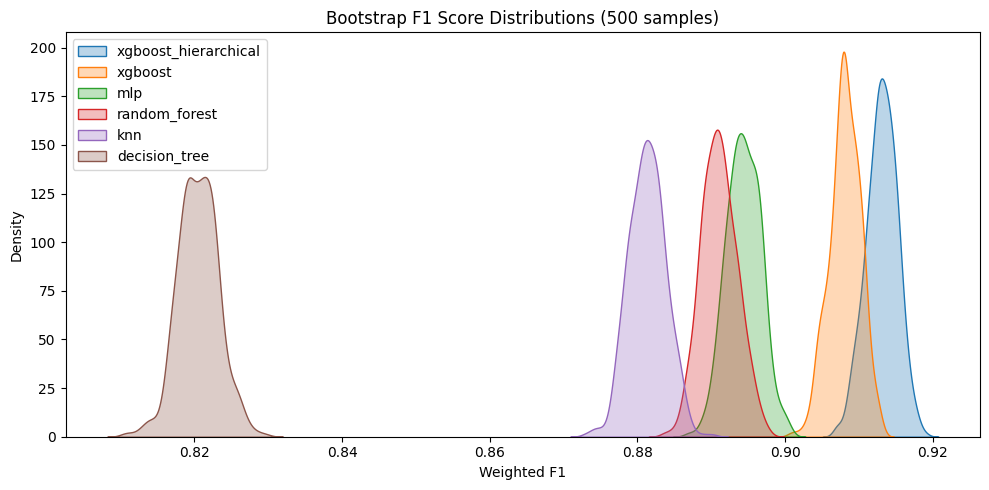

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for model in bootstrap_df.index:
    sns.kdeplot(bootstrap_scores[model], ax=ax, label=model, fill=True, alpha=0.3)

ax.set_xlabel('Weighted F1')
ax.set_title('Bootstrap F1 Score Distributions (500 samples)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/bootstrap_distributions.png', dpi=150)
plt.show()


**Cochran's Q Test**
All six models are statistically different from each other as a group (Q=1556.28, p<0.0001).

**Pairwise McNemar's Tests (Bonferroni corrected)**
9 out of 10 pairs among the base models are significantly different. The one exception is
Random Forest vs MLP (p=0.13), meaning their performance difference is statistically
indistinguishable. The hierarchical XGBoost is significantly better than all base models
(McNemar p=0.000002).

**Bootstrap Confidence Intervals (500 samples)**
- Hierarchical XGBoost: 0.909 to 0.917  best model, overlaps only with XGBoost
- XGBoost: 0.904 to 0.912  overlaps only with hierarchical XGBoost
- MLP: 0.890 to 0.899
- Random Forest: 0.887 to 0.896  overlaps heavily with MLP
- KNN: 0.877 to 0.886  clearly separated from the top three
- Decision Tree: 0.815 to 0.826  isolated far below all other models

**Conclusions**
- The hierarchical XGBoost is the best model by a statistically significant margin (p=0.000002)
- Among single models, XGBoost is best. Random Forest and MLP are statistically equivalent
- Given that RF trains in 1h 44m vs MLP's 11h 13m, RF is the better practical choice between the two
- Decision Tree is in a performance class of its own, significantly worse than all other models
- These results hold under uncertainty quantification: the bootstrap distributions confirm that
  the rankings are stable and not an artifact of the specific test set sampled

## 3. Agreement and Error Analysis


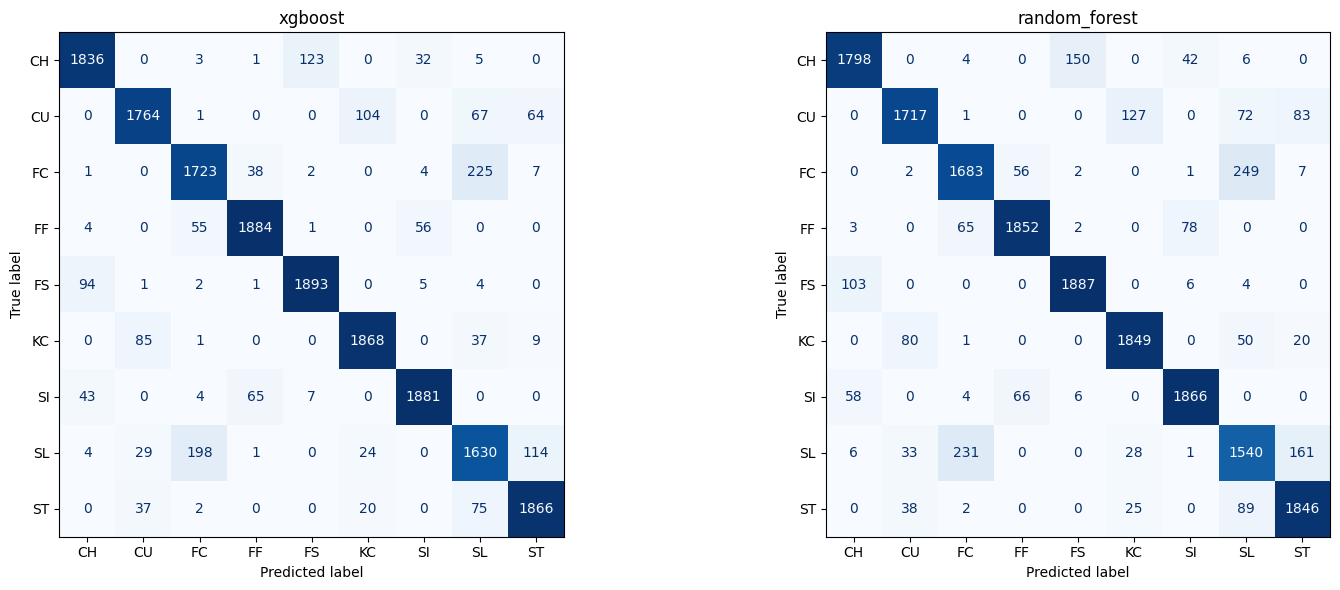

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model in zip(axes, ['xgboost', 'random_forest']):
    cm = confusion_matrix(df['y_true'], df[f'{model}_pred'], labels=CLASSES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(model)

plt.tight_layout()
plt.savefig('../results/figures/confusion_matrices.png', dpi=150)
plt.show()


In [11]:
correct = pd.DataFrame({
    model: (df[f'{model}_pred'] == df['y_true'])
    for model in EVAL_MODELS
})

df['n_correct'] = correct.sum(axis=1)

agreement_counts = df['n_correct'].value_counts().sort_index()
print('Models correct per row:')
for n, count in agreement_counts.items():
    pct = count / len(df) * 100
    print(f'  {n}/5 correct: {count:>5} rows ({pct:.1f}%)')


Models correct per row:
  0/5 correct:   592 rows (3.3%)
  1/5 correct:   458 rows (2.5%)
  2/5 correct:   405 rows (2.2%)
  3/5 correct:   459 rows (2.5%)
  4/5 correct:   752 rows (4.2%)
  5/5 correct:  2082 rows (11.6%)
  6/5 correct: 13252 rows (73.6%)


In [12]:
FEATURES = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate',
            'spin_axis', 'release_pos_x', 'release_pos_z', 'p_throws']

all_wrong = df[df['n_correct'] == 0]
print(f'Rows where all models failed: {len(all_wrong)} ({len(all_wrong)/len(df)*100:.1f}%)')
print()
print('True pitch type distribution:')
print(all_wrong['y_true'].value_counts())
print()
print('Feature means vs full test set:')
comparison = pd.DataFrame({
    'all_wrong': all_wrong[FEATURES].mean(),
    'full_test': df[FEATURES].mean()
}).round(3)
print(comparison)


Rows where all models failed: 592 (3.3%)

True pitch type distribution:
y_true
SL    145
CU    112
FC     89
CH     66
FF     48
ST     41
SI     40
FS     33
KC     18
Name: count, dtype: int64

Feature means vs full test set:
                   all_wrong  full_test
release_speed         86.119     86.267
pfx_x                  0.113     -0.038
pfx_z                  0.212      0.222
release_spin_rate   2277.764   2207.612
spin_axis            150.167    163.591
release_pos_x         -1.255     -0.975
release_pos_z          5.762      5.784
p_throws               0.836      0.765


In [13]:
xgb_only = df[
    (df['xgboost_pred'] == df['y_true']) &
    (df['random_forest_pred'] != df['y_true']) &
    (df['mlp_pred'] != df['y_true'])
]

print(f'Rows where only XGBoost correct (RF and MLP both wrong): {len(xgb_only)} ({len(xgb_only)/len(df)*100:.1f}%)')
print()
print('Pitch type distribution:')
print(xgb_only['y_true'].value_counts())
print()
print('What RF predicted on these rows:')
print(xgb_only['random_forest_pred'].value_counts())
print()
print('What MLP predicted on these rows:')
print(xgb_only['mlp_pred'].value_counts())


Rows where only XGBoost correct (RF and MLP both wrong): 232 (1.3%)

Pitch type distribution:
y_true
SL    54
FC    42
CU    33
CH    27
KC    17
SI    17
FF    16
FS    15
ST    11
Name: count, dtype: int64

What RF predicted on these rows:
random_forest_pred
SL    51
ST    39
FC    24
CH    22
KC    20
FS    20
CU    19
SI    19
FF    18
Name: count, dtype: int64

What MLP predicted on these rows:
mlp_pred
SL    46
ST    39
CU    25
FC    24
CH    21
FS    20
SI    20
KC    19
FF    18
Name: count, dtype: int64


**Confusion matrices (XGBoost and RF):**
Both models share nearly identical confusion patterns, consistent with their
statistically equivalent performance. The main error cluster involves SL, FC,
and ST. SL pitches are predicted as FC or ST, and FC pitches are predicted as SL.
This is a data-driven limitation, not a modeling artifact.

**Per-row agreement:**
- 73.6% of test rows: all 6 models correct. These are unambiguous pitches.
- 3.3% of test rows: all 6 models wrong. These are genuinely ambiguous pitches
  that the feature set cannot resolve.
- The remaining 23.1% represent borderline cases where models disagree.

**All models wrong (592 rows):**
SL (24%), CU (19%), and FC (15%) account for most failures. Critically, the
feature means of these rows are nearly identical to the full test set, meaning
these are not outliers. They sit at the exact boundaries where pitch types
overlap in feature space. No model can reliably classify them with the current
feature set.

**XGBoost unique successes (232 rows, 1.3%):**
XGBoost resolves some borderline SL and FC cases that both RF and MLP fail on.
RF and MLP predictions on these rows are scattered with no clear pattern,
suggesting XGBoost learned a more precise decision boundary in the SL/FC/ST
region specifically.


## 4. Per-class Deep Dive


In [ ]:
difficulty = per_class[EVAL_MODELS].mean(axis=1).sort_values().reset_index()
difficulty.columns = ['pitch_type', 'mean_f1']
difficulty['mean_f1'] = difficulty['mean_f1'].round(4)
difficulty

,pitch_type,mean_f1
0,SL,0.7723
1,FC,0.8451
2,CU,0.8688
3,ST,0.8951
4,CH,0.8952
5,KC,0.9047
6,FS,0.9220
7,FF,0.9292
8,SI,0.9298


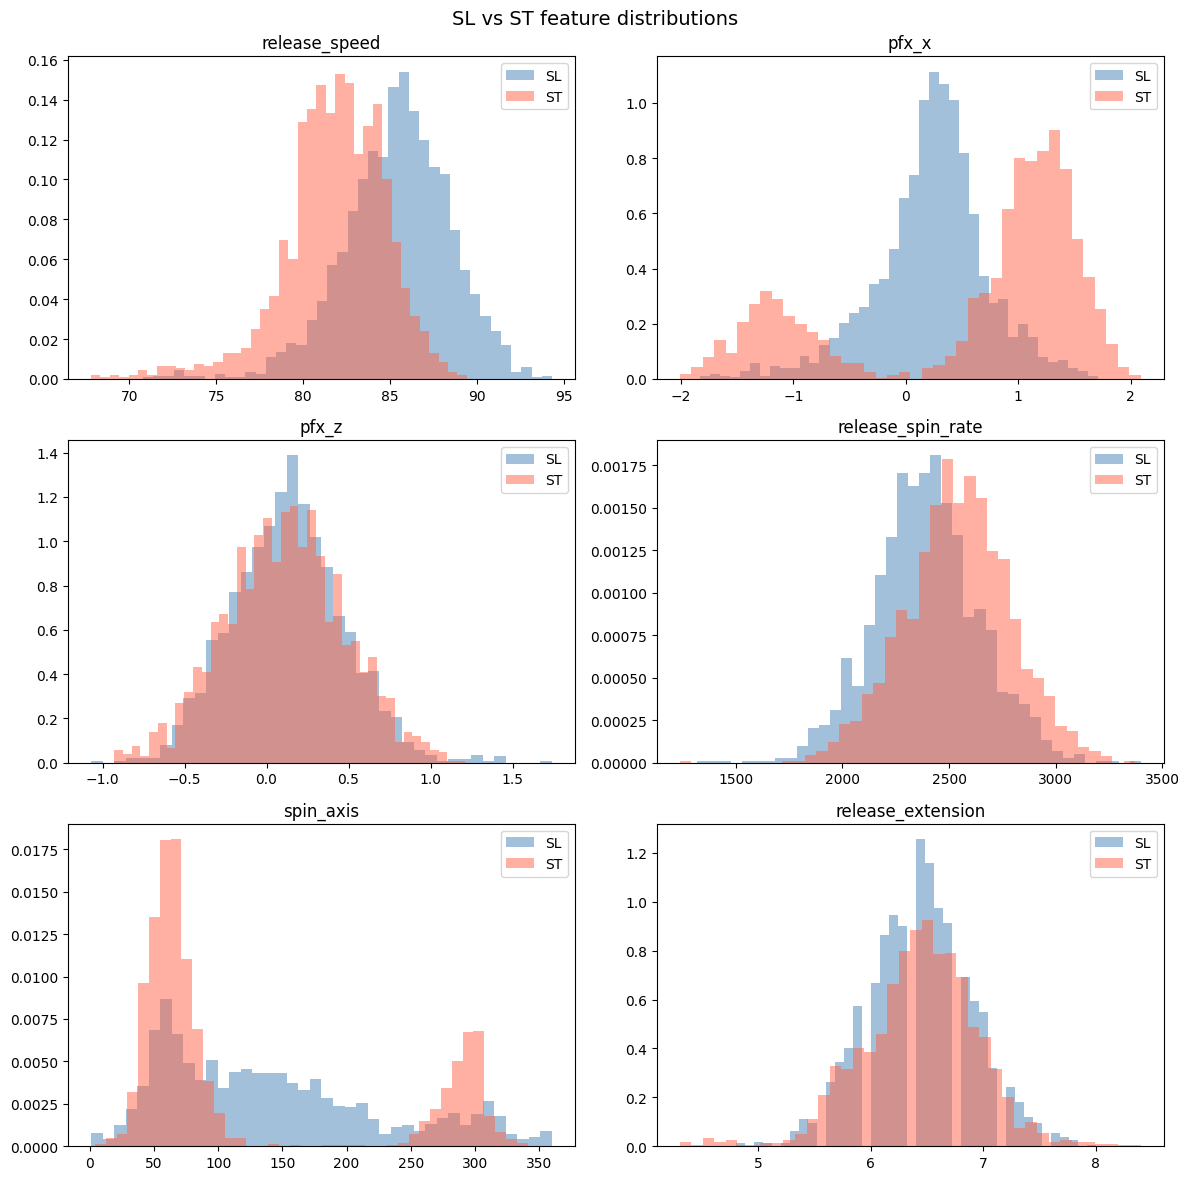

In [15]:
PLOT_FEATURES = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate', 'spin_axis', 'release_extension']

sl_st = df[df['y_true'].isin(['SL', 'ST'])][PLOT_FEATURES + ['y_true']]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, feature in zip(axes, PLOT_FEATURES):
    for pitch_type, color in zip(['SL', 'ST'], ['steelblue', 'tomato']):
        subset = sl_st[sl_st['y_true'] == pitch_type][feature]
        ax.hist(subset, bins=40, alpha=0.5, label=pitch_type, color=color, density=True)
    ax.set_title(feature)
    ax.legend()

fig.suptitle('SL vs ST feature distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/sl_vs_st_distributions.png', dpi=150)
plt.show()


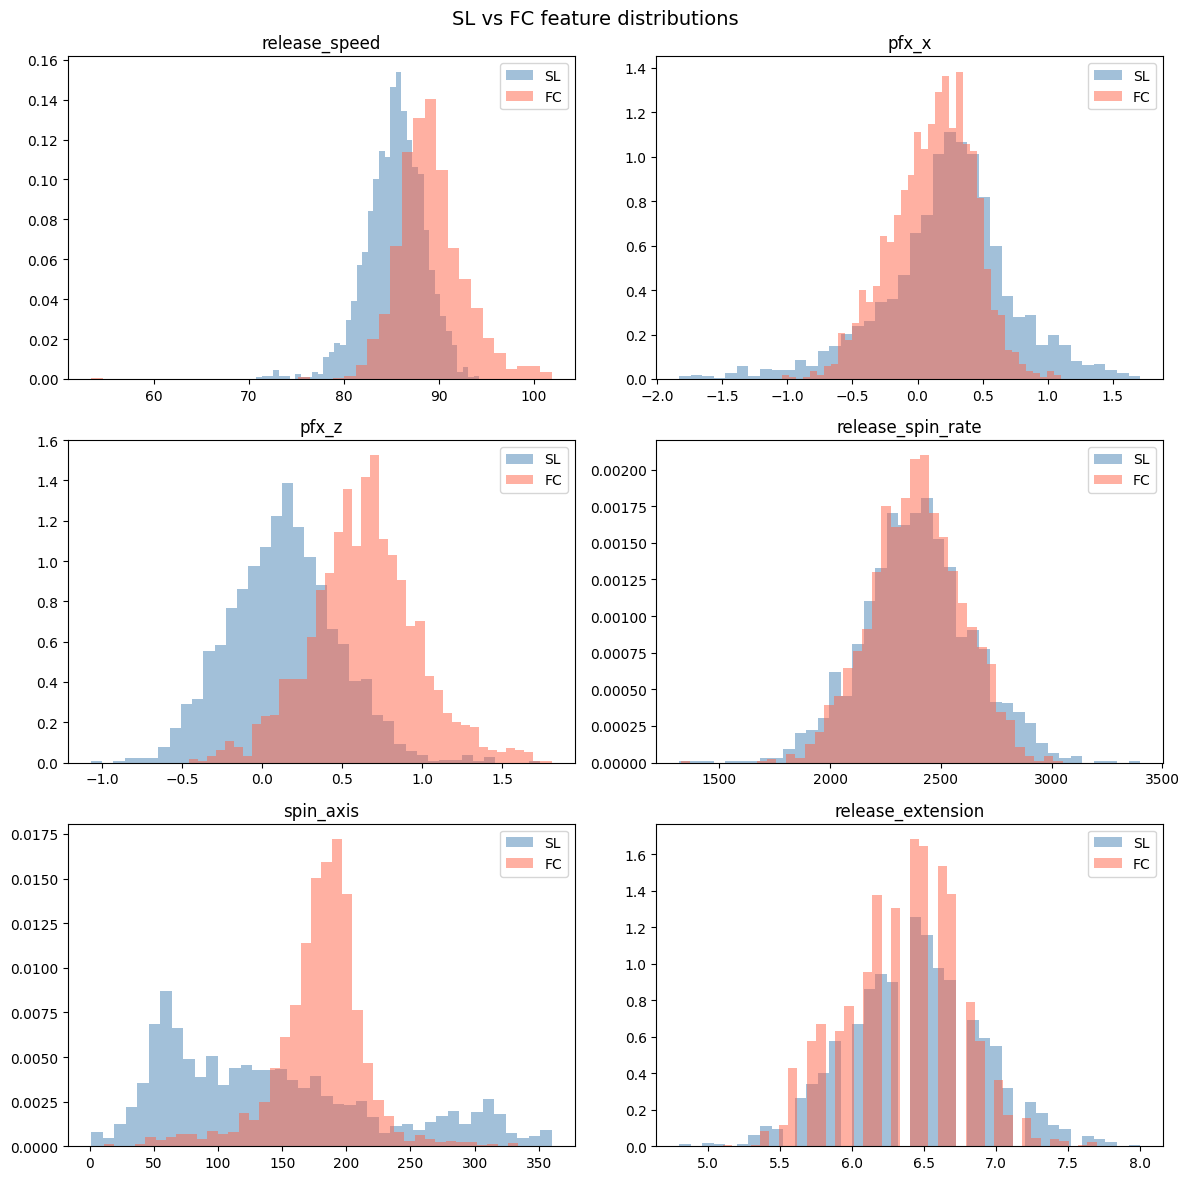

In [16]:
PLOT_FEATURES = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate', 'spin_axis', 'release_extension']

sl_fc = df[df['y_true'].isin(['SL', 'FC'])][PLOT_FEATURES + ['y_true']]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, feature in zip(axes, PLOT_FEATURES):
    for pitch_type, color in zip(['SL', 'FC'], ['steelblue', 'tomato']):
        subset = sl_fc[sl_fc['y_true'] == pitch_type][feature]
        ax.hist(subset, bins=40, alpha=0.5, label=pitch_type, color=color, density=True)
    ax.set_title(feature)
    ax.legend()

fig.suptitle('SL vs FC feature distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/sl_vs_fc_distributions.png', dpi=150)
plt.show()


**Difficulty ranking:**
SL and FC are in a different performance tier from all other pitch types.
SL (mean F1=0.77) is the hardest class by a significant margin. The next
hardest class (CU at 0.87) is already well above it. All other classes
sit between 0.90 and 0.93.

**SL vs ST:**
No single feature cleanly separates these two classes. pfx_z and
release_spin_rate are nearly identical between them. Release speed provides
slight separation (ST ~81 mph, SL ~85 mph) but with heavy overlap. Spin axis
is the most useful feature, with ST clustering lower than SL. The observed
bimodality in pfx_x and spin_axis is caused by pitcher handedness, not noise,
and is expected given that horizontal movement reverses direction between
left-handed and right-handed pitchers.

**SL vs FC:**
Release speed is the strongest separator (FC ~89 mph, SL ~85 mph) but the
tails overlap significantly. Spin axis separates them well, with FC clustering
tightly around 175-200 degrees and SL sitting lower. Release spin rate provides
almost no separating power between these two classes.

Neither pair can be cleanly separated by any individual feature. Models must
combine multiple features simultaneously, and even then the boundary regions
contain genuinely ambiguous pitches. The 3.3% of test rows where all models
failed are concentrated in exactly these classes. This is a data limitation,
not a modeling failure. Adding more data or tuning hyperparameters further
will not resolve the SL/ST and SL/FC confusion.


## 5. Feature Importance


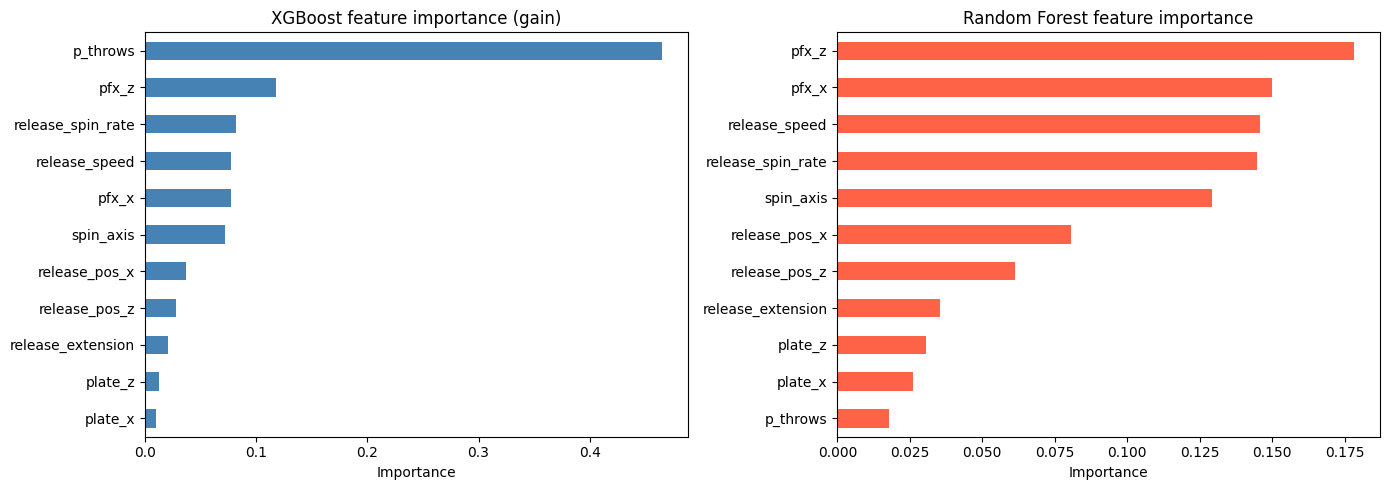

In [17]:
import joblib

xgb_pipeline = joblib.load('../results/models/xgboost.pkl')
rf_pipeline   = joblib.load('../results/models/random_forest.pkl')

FEATURES = ['release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z',
            'release_pos_x', 'release_pos_z', 'plate_x', 'plate_z',
            'release_extension', 'p_throws', 'spin_axis']

xgb_importance = pd.Series(
    xgb_pipeline.named_steps['model'].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

rf_importance = pd.Series(
    rf_pipeline.named_steps['model'].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xgb_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost feature importance (gain)')
axes[0].set_xlabel('Importance')

rf_importance.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Random Forest feature importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=150)
plt.show()

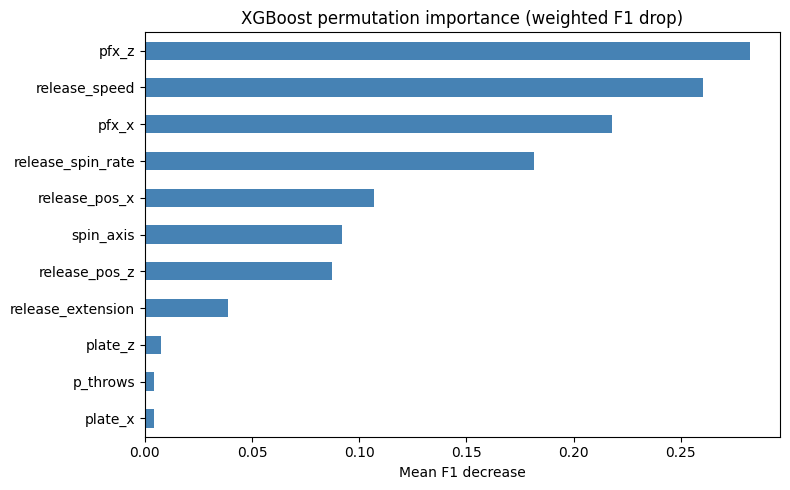

In [18]:
from sklearn.inspection import permutation_importance

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

class_map = {i: label for i, label in enumerate(sorted(y_test.unique()))}

def xgb_f1_scorer(estimator, X, y):
    preds = estimator.predict(X)
    if pd.api.types.is_numeric_dtype(pd.Series(preds)):
        preds = pd.Series(preds).map(class_map).values
    return f1_score(y, preds, average='weighted')

result = permutation_importance(
    xgb_pipeline, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring=xgb_f1_scorer
)

perm_importance = pd.Series(
    result.importances_mean,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
perm_importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost permutation importance (weighted F1 drop)')
ax.set_xlabel('Mean F1 decrease')
plt.tight_layout()
plt.savefig('../results/figures/permutation_importance.png', dpi=150)
plt.show()

**Built-in importance (XGBoost gain):**
p_throws dominates at 0.46, dwarfing all other features. This is an artifact
of how gain-based importance works: a binary feature that splits the entire
dataset cleanly on the first split accumulates enormous credit regardless of
whether it carries unique information.

**Built-in importance (Random Forest):**
Importance is distributed evenly across pfx_z, pfx_x, release_speed,
release_spin_rate, and spin_axis. p_throws ranks last. RF's averaging across
many trees reduces the bias toward early high-gain splits.

**Permutation importance (XGBoost):**
pfx_z (0.28), release_speed (0.26), pfx_x (0.22), and release_spin_rate (0.18)
are the most important features. p_throws scores near zero (0.01), meaning
shuffling it barely hurts performance. The model can infer handedness from
pfx_x and release_pos_x, making p_throws largely redundant given the other
features.

Permutation importance gives the most honest picture. The physical pitch
mechanics, vertical movement, velocity, horizontal movement, and spin rate,
are what drive classification performance. p_throws is a useful structural
feature but not irreplaceable. Built-in importance should be interpreted
with caution due to its known bias toward high-gain early splits.


## Overall Conclusions

This project built and evaluated a pitch type classifier using 2023 MLB Statcast
data from all pitchers. The goal was to classify 9 pitch types from physical
measurements alone, with no pitcher identity information.

**Best model:** The hierarchical XGBoost (F1=0.9130) is the best performing
system, combining a 9-class base model with a specialist trained exclusively
on the three hardest classes (SL, FC, ST). The improvement over the base
XGBoost (F1=0.9081) is statistically significant (McNemar p=0.000002).

**Practical recommendation:** Among single models, XGBoost (F1=0.9081) is
the best performer and is significantly better than all others. Random Forest
(F1=0.8910) is a viable alternative, it is statistically equivalent to MLP
but trains in 1h 44m vs MLP's 11h 13m, making it the better practical choice
between those two.

**Hard classes:** SL (Slider) remains the hardest pitch type to classify
(mean F1=0.77 across all models). The feature distributions show that SL,
FC, and ST occupy overlapping regions in the feature space. 3.3% of test
pitches are genuinely ambiguous, no model can classify them correctly and
their feature values are indistinguishable from the rest of the test set.
This is a data limitation, not a modeling failure.

**Feature importance:** Permutation importance shows that pfx_z, release_speed,
pfx_x, and release_spin_rate drive classification performance. Pitcher
handedness (p_throws) is largely redundant given that horizontal movement
features already encode handedness implicitly.
